# Log Parsing & Sequence Statistics — Drain3 (BGL, Thunderbird, HDFS)

Notebook ini **khusus** untuk mengeksplorasi dua tahap awal pipeline deteksi anomali log
(Parsing dengan Drain3 dan Pembentukan Sekuens), **tanpa** melanjutkan ke embedding/VAE.

Yang dihasilkan:
1. **Statistik Parsing** — jumlah baris log, baris gagal parsing, jumlah *template unik*
   (event type) yang ditemukan Drain3, distribusi frekuensi template, template paling sering
   muncul, serta proporsi normal/anomali per baris (bila label tersedia per baris).
2. **Statistik Pembentukan Sekuens** — jumlah sekuens yang terbentuk, distribusi panjang
   sekuens (jumlah baris log per sekuens), jumlah template unik per sekuens, dan distribusi
   label sekuens (normal vs anomali).
3. **Visualisasi** untuk setiap dataset, serta **tabel & grafik perbandingan** lintas dataset.

Dataset yang didukung: **BGL**, **Thunderbird**, **HDFS** (bisa diproses satu, sebagian, atau
ketiganya sekaligus — atur di bagian Konfigurasi).

> Notebook ini disesuaikan agar bisa berjalan di Kaggle Notebooks (`/kaggle/input`,
> `/kaggle/working`) maupun secara lokal.


## 1. Instalasi Dependensi

In [1]:
# Drain3 biasanya belum tersedia di image Kaggle bawaan
!pip install -q drain3
print('Dependensi siap.')

  Preparing metadata (setup.py) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyiceberg 0.11.1 requires cachetools<7.0,>=5.5, but you have cachetools 4.2.1 which is incompatible.
Dependensi siap.


## 2. Import Library

In [2]:
import os, re, json
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
print('Library siap.')

Library siap.


## 3. Konfigurasi

In [3]:
# -- Deteksi otomatis apakah berjalan di Kaggle --
IS_KAGGLE = os.path.exists("/kaggle/input")
KAGGLE_DATASET_DIR = "/kaggle/input/datasets/shutterisland/log-system-detection-anomaly"
LOCAL_DATASET_DIR  = "../Dataset"

DATASET_DIR = KAGGLE_DATASET_DIR if IS_KAGGLE else LOCAL_DATASET_DIR

# Daftar dataset yang ingin diproses. Hapus/comment entri yang tidak diperlukan.
DATASETS_TO_RUN = [
    {
        "dataset_name"    : "BGL",
        "log_file"        : f"{DATASET_DIR}/BGL.log",
        "hdfs_label_file" : None,
        "window_size"     : 20,     # sliding-window (dipakai untuk BGL/Thunderbird)
    },
    {
        "dataset_name"    : "Thunderbird",
        "log_file"        : f"{DATASET_DIR}/Thunderbird.log",
        "hdfs_label_file" : None,
        "window_size"     : 20,
    },
    {
        "dataset_name"    : "HDFS",
        "log_file"        : f"{DATASET_DIR}/HDFS.log",
        "hdfs_label_file" : f"{DATASET_DIR}/anomaly_label.csv",
        "window_size"     : None,   # HDFS memakai skema Block-ID, bukan sliding window
    },
]

MAX_LINES  = None          # set angka untuk membatasi baris yang dibaca (debug cepat)
TOP_N_TEMPLATES = 20        # jumlah template teratas yang divisualisasikan
OUTPUT_DIR = "/kaggle/working/outputs_parsing_stats" if IS_KAGGLE else "./outputs_parsing_stats"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Berjalan di Kaggle : {IS_KAGGLE}")
print(f"Dataset dir        : {DATASET_DIR}")
print(f"Output dir         : {OUTPUT_DIR}")
print(f"Dataset yang diproses:")
for d in DATASETS_TO_RUN:
    print(f"  - {d['dataset_name']}: {d['log_file']}")

if IS_KAGGLE:
    missing = [d for d in DATASETS_TO_RUN if not os.path.exists(d["log_file"])]
    if missing:
        print("\n[PERINGATAN] File log berikut tidak ditemukan:")
        for d in missing:
            print("  -", d["log_file"])
        print("Isi folder /kaggle/input yang tersedia saat ini:")
        for d_ in os.listdir("/kaggle/input"):
            print("  -", d_)
        print("Perbarui DATASET_DIR / DATASETS_TO_RUN di atas agar sesuai.")

Berjalan di Kaggle : True
Dataset dir        : /kaggle/input/datasets/shutterisland/log-system-detection-anomaly
Output dir         : /kaggle/working/outputs_parsing_stats
Dataset yang diproses:
  - BGL: /kaggle/input/datasets/shutterisland/log-system-detection-anomaly/BGL.log
  - Thunderbird: /kaggle/input/datasets/shutterisland/log-system-detection-anomaly/Thunderbird.log
  - HDFS: /kaggle/input/datasets/shutterisland/log-system-detection-anomaly/HDFS.log

[PERINGATAN] File log berikut tidak ditemukan:
  - /kaggle/input/datasets/shutterisland/log-system-detection-anomaly/Thunderbird.log
Isi folder /kaggle/input yang tersedia saat ini:
  - datasets
Perbarui DATASET_DIR / DATASETS_TO_RUN di atas agar sesuai.


## 4. Pola Regex per Dataset & Drain3 Template Miner

Setiap dataset memiliki format header yang berbeda. Bagian `content` (pesan aktual, setelah
metadata seperti timestamp/komponen dibuang) yang diumpankan ke Drain3 untuk *template mining*.

In [4]:
DATASET_PATTERNS = {
    "BGL": {
        # format: <label> <...metadata...> <message>
        # label = '-' (normal) atau kode kesalahan (anomali)
        "regex": r"^(?P<label>\S+)\s+(?P<timestamp>\S+)\s+(?P<date>\S+)\s+(?P<node>\S+)\s+(?P<time>\S+)\s+(?P<nodeRepeat>\S+)\s+(?P<type>\S+)\s+(?P<component>\S+)\s+(?P<level>\S+)\s+(?P<content>.+)$",
        "label_field": "label",
        "normal_label": "-",
        "content_field": "content",
    },
    "Thunderbird": {
        "regex": r"^(?P<label>\S+)\s+(?P<timestamp>\S+)\s+(?P<date>\S+)\s+(?P<user>\S+)\s+(?P<month>\S+)\s+(?P<day>\S+)\s+(?P<time>\S+)\s+(?P<location>\S+)\s+(?P<component>\S+)(\[(?P<pid>\d+)\])?:\s+(?P<content>.+)$",
        "label_field": "label",
        "normal_label": "-",
        "content_field": "content",
    },
    "HDFS": {
        # Format tiap baris: <date> <time> <pid> <level> <component>: <content>
        # Label tidak ada per-baris — dibaca dari CSV terpisah (per Block ID)
        "regex": r"^(?P<date>\d{6})\s+(?P<time>\d{6})\s+(?P<pid>\d+)\s+(?P<level>\S+)\s+(?P<component>\S+):\s+(?P<content>.+)$",
        "label_field": None,
        "normal_label": None,
        "content_field": "content",
    },
}

# Regex untuk mengekstrak semua Block ID dari satu baris log HDFS
HDFS_BLOCK_RE = re.compile(r"blk_-?\d+")


def build_drain3_miner() -> TemplateMiner:
    """Bangun instance Drain3 TemplateMiner dengan konfigurasi default."""
    config = TemplateMinerConfig()
    config.drain_sim_th = 0.4
    config.drain_depth = 4
    config.drain_max_children = 100
    config.parametrize_numeric_tokens = True
    return TemplateMiner(config=config)


def load_hdfs_labels(label_file: str) -> dict:
    """Muat label per Block ID dari file CSV. Returns dict {block_id -> 0/1}."""
    df = pd.read_csv(label_file)
    df.columns = [c.strip().lower() for c in df.columns]
    if "blockid" not in df.columns or "label" not in df.columns:
        raise ValueError(
            f"File CSV label HDFS harus memiliki kolom 'BlockId' dan 'Label'. "
            f"Kolom yang ditemukan: {list(df.columns)}"
        )
    label_map = {}
    for _, row in df.iterrows():
        bid = str(row["blockid"]).strip()
        lbl = 0 if str(row["label"]).strip().lower() == "normal" else 1
        label_map[bid] = lbl
    print(f"Label HDFS dimuat: {len(label_map):,} block ID")
    print(f"  Normal  : {sum(1 for v in label_map.values() if v==0):,}")
    print(f"  Anomali : {sum(1 for v in label_map.values() if v==1):,}")
    return label_map

## 5. Fungsi Parsing (Drain3) + Pengumpulan Statistik Template

In [5]:
def parse_logs(log_file: str, dataset_name: str, max_lines: int = None,
               hdfs_label_file: str = None):
    """
    Baca dan parsing log mentah dengan Drain3.

    Returns
    -------
    df : pd.DataFrame
        Kolom: 'raw', 'content', 'template', 'template_id', 'label', dan
        (khusus HDFS) 'block_ids'
    hdfs_label_map : dict | None
    miner : TemplateMiner
        Instance miner setelah parsing (berisi seluruh cluster/template yang ditemukan)
    n_failed : int
        Jumlah baris yang gagal dicocokkan dengan regex dataset
    """
    pattern_cfg = DATASET_PATTERNS.get(dataset_name)
    if pattern_cfg is None:
        raise ValueError(f"Dataset '{dataset_name}' tidak dikenal. Pilih: {list(DATASET_PATTERNS.keys())}")

    regex = re.compile(pattern_cfg["regex"])
    miner = build_drain3_miner()

    hdfs_label_map = None
    if dataset_name == "HDFS":
        if not hdfs_label_file:
            raise ValueError("Untuk dataset HDFS, parameter 'hdfs_label_file' wajib diisi.")
        hdfs_label_map = load_hdfs_labels(hdfs_label_file)

    records = []
    failed  = 0

    print(f"Membaca file: {log_file}")
    with open(log_file, "r", encoding="utf-8", errors="replace") as f:
        for i, line in enumerate(tqdm(f, desc=f"Parsing [{dataset_name}]")):
            if max_lines and i >= max_lines:
                break
            line = line.rstrip("\n")
            m = regex.match(line)
            if not m:
                failed += 1
                continue

            content  = m.group(pattern_cfg["content_field"]).strip()
            result   = miner.add_log_message(content)
            template = result["template_mined"] if result else content
            template_id = result["cluster_id"] if result else -1

            if dataset_name == "HDFS":
                block_ids = HDFS_BLOCK_RE.findall(content)
                label     = -1
            elif pattern_cfg["label_field"]:
                raw_label = m.group(pattern_cfg["label_field"])
                label     = 0 if raw_label == pattern_cfg["normal_label"] else 1
                block_ids = []
            else:
                label     = -1
                block_ids = []

            records.append({
                "raw"        : line,
                "content"    : content,
                "template"   : template,
                "template_id": template_id,
                "label"      : label,
                "block_ids"  : block_ids,
            })

    df = pd.DataFrame(records)
    print(f"\nTotal baris berhasil diparsing : {len(df):,}")
    print(f"Baris gagal diparsing          : {failed:,}")
    print(f"Jumlah template unik (Drain3)  : {df['template_id'].nunique():,}")
    if dataset_name != "HDFS" and -1 not in df["label"].values:
        print(f"Normal  : {(df['label']==0).sum():,}")
        print(f"Anomali : {(df['label']==1).sum():,}")
    return df, hdfs_label_map, miner, failed

## 6. Fungsi Pembentukan Sekuens (Sliding Window / Block-ID)

In [6]:
def create_windows(df: pd.DataFrame, window_size: int):
    """Sekuens non-overlap dari baris log (BGL / Thunderbird)."""
    templates    = df["template"].tolist()
    template_ids = df["template_id"].tolist()
    labels       = df["label"].tolist()
    windows = []

    for start in range(0, len(templates) - window_size + 1, window_size):
        end   = start + window_size
        texts = templates[start:end]
        tids  = template_ids[start:end]
        lbls  = labels[start:end]

        valid = [l for l in lbls if l != -1]
        if not valid:
            seq_label = -1
        elif any(l == 1 for l in valid):
            seq_label = 1
        else:
            seq_label = 0

        windows.append({"texts": texts, "template_ids": tids, "label": seq_label})

    return windows


def create_windows_hdfs(df: pd.DataFrame, label_map: dict):
    """Sekuens per Block ID untuk dataset HDFS."""
    block_to_rows: dict = defaultdict(list)
    for row_idx, row in df.iterrows():
        for bid in row["block_ids"]:
            block_to_rows[bid].append(row_idx)

    windows = []
    for bid, row_indices in block_to_rows.items():
        texts     = df.loc[row_indices, "template"].tolist()
        tids      = df.loc[row_indices, "template_id"].tolist()
        seq_label = label_map.get(bid, -1)
        windows.append({"texts": texts, "template_ids": tids, "label": seq_label, "block_id": bid})

    return windows


def print_window_stats(windows, scheme_name: str):
    n_total   = len(windows)
    n_normal  = sum(1 for w in windows if w["label"] == 0)
    n_anomaly = sum(1 for w in windows if w["label"] == 1)
    n_unknown = sum(1 for w in windows if w["label"] == -1)
    print(f"Sekuens ({scheme_name}): {n_total:,} total")
    print(f"  Normal  : {n_normal:,}")
    print(f"  Anomali : {n_anomaly:,}")
    if n_unknown:
        print(f"  Unknown : {n_unknown:,}")

## 7. Fungsi Perhitungan Statistik Parsing & Sekuens

In [7]:
def compute_parsing_stats(df: pd.DataFrame, dataset_name: str, n_failed: int) -> dict:
    """Statistik seputar tahap parsing/template-mining Drain3."""
    template_counts = df["template"].value_counts()
    n_lines = len(df)

    stats = {
        "dataset_name"        : dataset_name,
        "total_lines_read"    : int(n_lines + n_failed),
        "lines_parsed_ok"     : int(n_lines),
        "lines_failed_parse"  : int(n_failed),
        "parse_success_rate"  : round(n_lines / max(1, n_lines + n_failed), 4),
        "n_unique_templates"  : int(df["template_id"].nunique()),
        "template_freq_top"   : [
            {"template": t[:120], "count": int(c)}
            for t, c in template_counts.head(TOP_N_TEMPLATES).items()
        ],
        "template_freq_stats" : {
            "min"   : int(template_counts.min()),
            "median": float(template_counts.median()),
            "mean"  : float(template_counts.mean()),
            "max"   : int(template_counts.max()),
        },
    }

    if dataset_name != "HDFS" and -1 not in df["label"].values:
        stats["line_label_counts"] = {
            "normal" : int((df["label"] == 0).sum()),
            "anomaly": int((df["label"] == 1).sum()),
        }
    else:
        stats["line_label_counts"] = None

    return stats, template_counts


def compute_sequence_stats(windows: list, dataset_name: str) -> dict:
    """Statistik seputar tahap pembentukan sekuens."""
    seq_lengths       = np.array([len(w["texts"]) for w in windows])
    unique_tpl_per_seq = np.array([len(set(w["template_ids"])) for w in windows])
    labels            = np.array([w["label"] for w in windows])

    stats = {
        "dataset_name"       : dataset_name,
        "n_sequences"        : int(len(windows)),
        "label_counts"       : {
            "normal" : int((labels == 0).sum()),
            "anomaly": int((labels == 1).sum()),
            "unknown": int((labels == -1).sum()),
        },
        "seq_length_stats"   : {
            "min"   : int(seq_lengths.min()) if len(seq_lengths) else 0,
            "median": float(np.median(seq_lengths)) if len(seq_lengths) else 0,
            "mean"  : float(seq_lengths.mean()) if len(seq_lengths) else 0,
            "p90"   : float(np.percentile(seq_lengths, 90)) if len(seq_lengths) else 0,
            "p99"   : float(np.percentile(seq_lengths, 99)) if len(seq_lengths) else 0,
            "max"   : int(seq_lengths.max()) if len(seq_lengths) else 0,
        },
        "unique_template_per_seq_stats": {
            "min"   : int(unique_tpl_per_seq.min()) if len(unique_tpl_per_seq) else 0,
            "median": float(np.median(unique_tpl_per_seq)) if len(unique_tpl_per_seq) else 0,
            "mean"  : float(unique_tpl_per_seq.mean()) if len(unique_tpl_per_seq) else 0,
            "max"   : int(unique_tpl_per_seq.max()) if len(unique_tpl_per_seq) else 0,
        },
    }
    return stats, seq_lengths, unique_tpl_per_seq, labels

## 8. Jalankan Parsing + Pembentukan Sekuens untuk Semua Dataset

Loop di bawah memproses setiap dataset pada `DATASETS_TO_RUN`, menyimpan hasil parsing,
statistik parsing, dan statistik sekuens ke dalam dict `all_results`.

In [8]:
all_results = {}   # dataset_name -> dict berisi df, windows, stats, dsb.

for d_cfg in DATASETS_TO_RUN:
    name = d_cfg["dataset_name"]
    print("\n" + "=" * 70)
    print(f"DATASET: {name}")
    print("=" * 70)

    if not os.path.exists(d_cfg["log_file"]):
        print(f"[SKIP] File log tidak ditemukan: {d_cfg['log_file']}")
        continue

    # ── Parsing ──────────────────────────────────────────────────────
    df, hdfs_label_map, miner, n_failed = parse_logs(
        d_cfg["log_file"], name, MAX_LINES,
        hdfs_label_file=d_cfg.get("hdfs_label_file"),
    )
    parsing_stats, template_counts = compute_parsing_stats(df, name, n_failed)

    # ── Pembentukan Sekuens ─────────────────────────────────────────
    if name == "HDFS":
        if hdfs_label_map is None:
            print("[SKIP] Label HDFS tidak tersedia, tidak bisa membentuk sekuens.")
            continue
        windows = create_windows_hdfs(df, hdfs_label_map)
        scheme  = "HDFS block-ID"
    else:
        windows = create_windows(df, d_cfg["window_size"])
        scheme  = f"sliding-window (size={d_cfg['window_size']})"
    print_window_stats(windows, scheme)

    seq_stats, seq_lengths, unique_tpl_per_seq, seq_labels = compute_sequence_stats(windows, name)

    all_results[name] = {
        "df"                : df,
        "windows"           : windows,
        "scheme"            : scheme,
        "parsing_stats"     : parsing_stats,
        "template_counts"   : template_counts,
        "seq_stats"         : seq_stats,
        "seq_lengths"       : seq_lengths,
        "unique_tpl_per_seq": unique_tpl_per_seq,
        "seq_labels"        : seq_labels,
    }

print("\n\nSelesai. Dataset yang berhasil diproses:", list(all_results.keys()))


DATASET: BGL
Membaca file: /kaggle/input/datasets/shutterisland/log-system-detection-anomaly/BGL.log


Parsing [BGL]: 0it [00:00, ?it/s]


Total baris berhasil diparsing : 4,713,493
Baris gagal diparsing          : 34,470
Jumlah template unik (Drain3)  : 1,822
Normal  : 4,365,033
Anomali : 348,460
Sekuens (sliding-window (size=20)): 235,674 total
  Normal  : 215,418
  Anomali : 20,256

DATASET: Thunderbird
[SKIP] File log tidak ditemukan: /kaggle/input/datasets/shutterisland/log-system-detection-anomaly/Thunderbird.log

DATASET: HDFS
Label HDFS dimuat: 575,061 block ID
  Normal  : 558,223
  Anomali : 16,838
Membaca file: /kaggle/input/datasets/shutterisland/log-system-detection-anomaly/HDFS.log


Parsing [HDFS]: 0it [00:00, ?it/s]


Total baris berhasil diparsing : 11,175,629
Baris gagal diparsing          : 0
Jumlah template unik (Drain3)  : 47
Sekuens (HDFS block-ID): 575,061 total
  Normal  : 558,223
  Anomali : 16,838


Selesai. Dataset yang berhasil diproses: ['BGL', 'HDFS']


## 9. Tabel Ringkasan Statistik Parsing (Lintas Dataset)

In [9]:
parsing_rows = []
for name, res in all_results.items():
    ps = res["parsing_stats"]
    row = {
        "Dataset"              : name,
        "Skema Sekuens"        : res["scheme"],
        "Total Baris Dibaca"   : ps["total_lines_read"],
        "Baris Berhasil Parse" : ps["lines_parsed_ok"],
        "Baris Gagal Parse"    : ps["lines_failed_parse"],
        "Success Rate"         : f"{ps['parse_success_rate']:.1%}",
        "Jumlah Template Unik" : ps["n_unique_templates"],
    }
    if ps["line_label_counts"]:
        row["Baris Normal"]  = ps["line_label_counts"]["normal"]
        row["Baris Anomali"] = ps["line_label_counts"]["anomaly"]
    parsing_rows.append(row)

parsing_summary_df = pd.DataFrame(parsing_rows)
parsing_summary_df

,Dataset,Skema Sekuens,Total Baris Dibaca,Baris Berhasil Parse,Baris Gagal Parse,Success Rate,Jumlah Template Unik,Baris Normal,Baris Anomali
0,BGL,sliding-window (size=20),4747963,4713493,34470,99.3%,1822,4365033.0,348460.0
1,HDFS,HDFS block-ID,11175629,11175629,0,100.0%,47,NaN,NaN


### Visualisasi: Jumlah Template Unik per Dataset

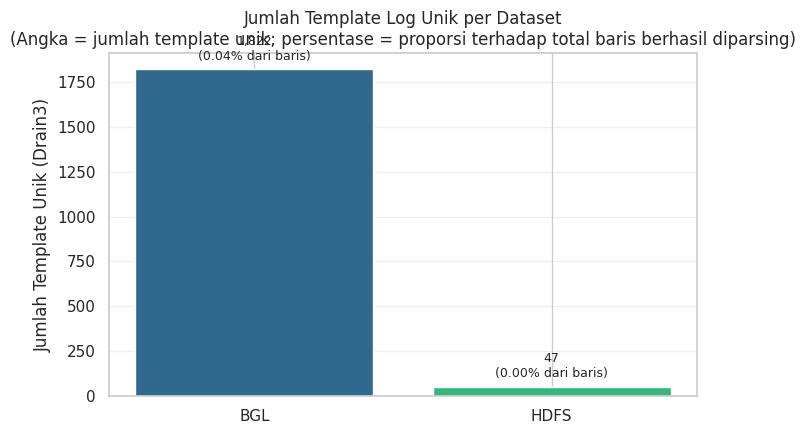

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
names       = list(all_results.keys())
n_templates = [all_results[n]["parsing_stats"]["n_unique_templates"] for n in names]
n_lines_ok  = [all_results[n]["parsing_stats"]["lines_parsed_ok"] for n in names]

bars = ax.bar(names, n_templates, color=sns.color_palette("viridis", len(names)))
for bar, nt, nl in zip(bars, n_templates, n_lines_ok):
    pct = 100 * nt / max(1, nl)
    ax.annotate(f"{nt:,}\n({pct:.2f}% dari baris)", xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 5), textcoords="offset points", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Jumlah Template Unik (Drain3)")
ax.set_title("Jumlah Template Log Unik per Dataset\n(Angka = jumlah template unik; persentase = proporsi terhadap total baris berhasil diparsing)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "unique_templates_per_dataset.png"), dpi=150)
plt.show()

### Visualisasi: Total Baris Log & Rasio Berhasil/Gagal Parse

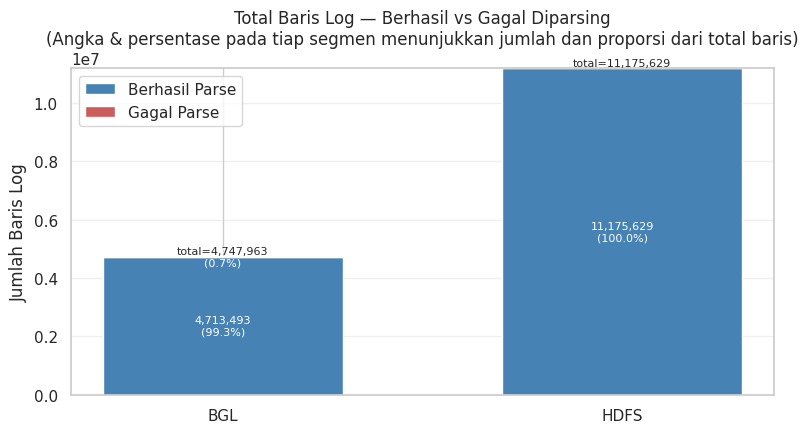

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ok_counts     = [all_results[n]["parsing_stats"]["lines_parsed_ok"] for n in names]
failed_counts = [all_results[n]["parsing_stats"]["lines_failed_parse"] for n in names]
totals        = [ok + fl for ok, fl in zip(ok_counts, failed_counts)]

x = np.arange(len(names))
width = 0.6
bars_ok = ax.bar(x, ok_counts, width, label="Berhasil Parse", color="steelblue")
bars_fail = ax.bar(x, failed_counts, width, bottom=ok_counts, label="Gagal Parse", color="indianred")

for xi, ok, fl, tot in zip(x, ok_counts, failed_counts, totals):
    pct_ok = 100 * ok / max(1, tot)
    pct_fail = 100 * fl / max(1, tot)
    ax.text(xi, ok / 2, f"{ok:,}\n({pct_ok:.1f}%)", ha="center", va="center", fontsize=8, color="white")
    if fl > 0:
        ax.text(xi, ok + fl / 2, f"{fl:,}\n({pct_fail:.1f}%)", ha="center", va="center", fontsize=8, color="white")
    ax.text(xi, tot, f"total={tot:,}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel("Jumlah Baris Log")
ax.set_title("Total Baris Log — Berhasil vs Gagal Diparsing\n(Angka & persentase pada tiap segmen menunjukkan jumlah dan proporsi dari total baris)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "parse_success_vs_failed.png"), dpi=150)
plt.show()

### Visualisasi per Dataset: Template Terbanyak & Distribusi Frekuensi Template

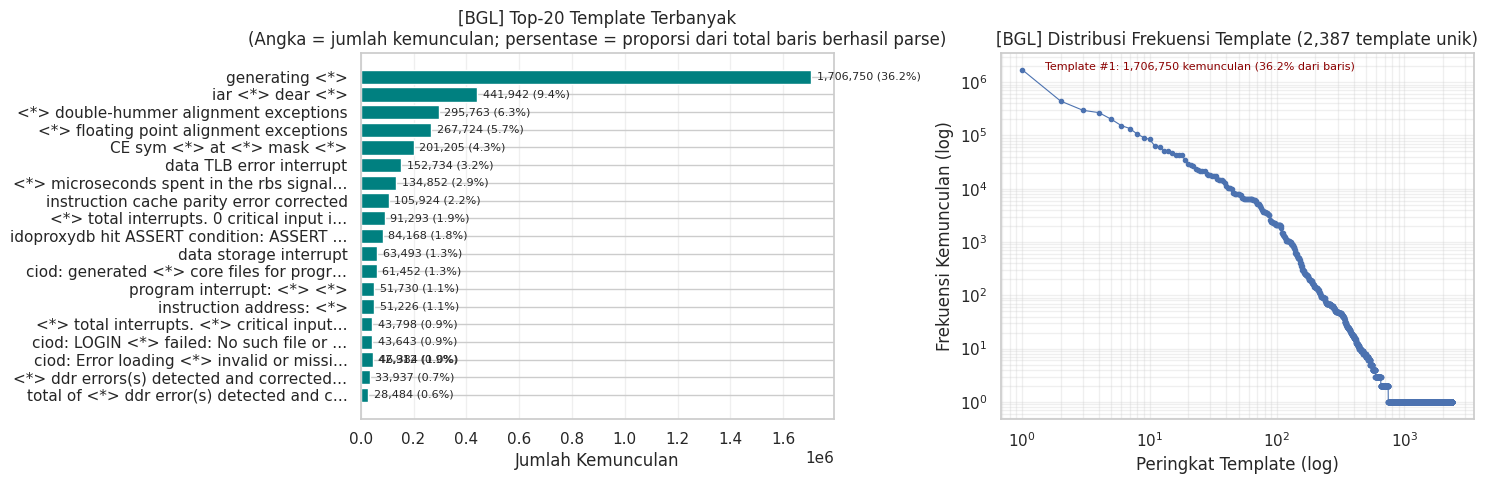

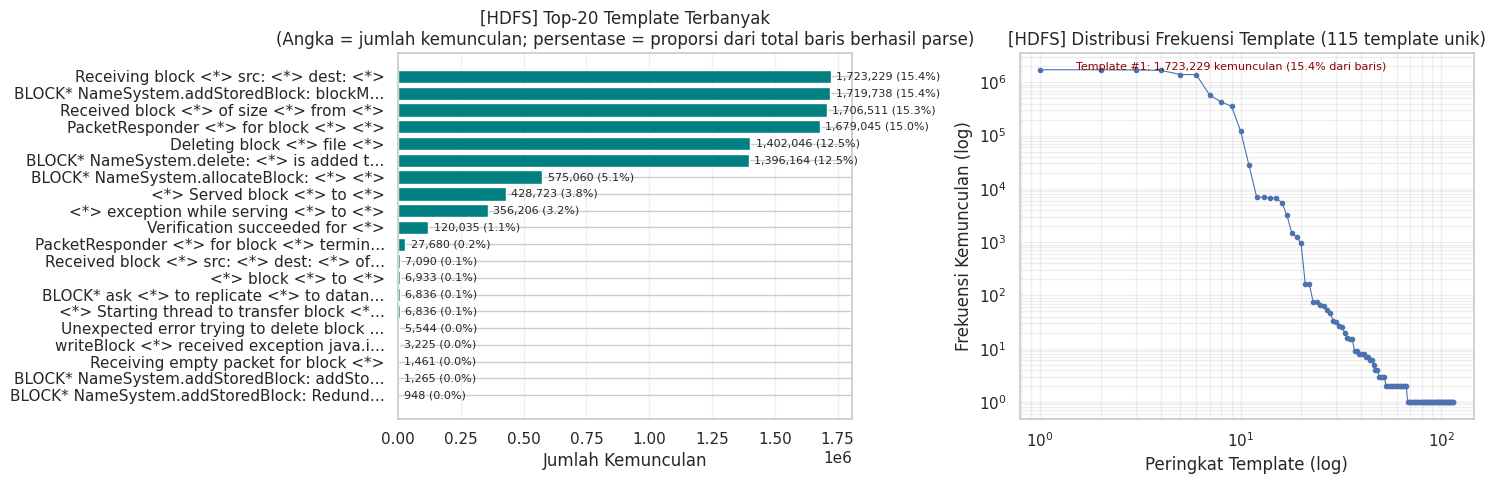

In [12]:
for name, res in all_results.items():
    tc = res["template_counts"]
    n_lines_ok = res["parsing_stats"]["lines_parsed_ok"]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # -- Top-N template paling sering muncul --
    top = tc.head(TOP_N_TEMPLATES)
    labels_short = [t[:40] + ("…" if len(t) > 40 else "") for t in top.index]
    bars = axes[0].barh(labels_short[::-1], top.values[::-1], color="teal")
    for bar, val in zip(bars, top.values[::-1]):
        pct = 100 * val / max(1, n_lines_ok)
        axes[0].annotate(f"{val:,} ({pct:.1f}%)", xy=(bar.get_width(), bar.get_y() + bar.get_height()/2),
                          xytext=(4, 0), textcoords="offset points", ha="left", va="center", fontsize=8)
    axes[0].set_title(f"[{name}] Top-{TOP_N_TEMPLATES} Template Terbanyak\n(Angka = jumlah kemunculan; persentase = proporsi dari total baris berhasil parse)")
    axes[0].set_xlabel("Jumlah Kemunculan")
    axes[0].grid(axis="x", alpha=0.3)

    # -- Distribusi frekuensi seluruh template (log-log, mengecek pola long-tail) --
    freqs_sorted = np.sort(tc.values)[::-1]
    axes[1].plot(np.arange(1, len(freqs_sorted) + 1), freqs_sorted, marker=".", lw=0.8)
    top1_pct = 100 * freqs_sorted[0] / max(1, n_lines_ok)
    axes[1].annotate(f"Template #1: {freqs_sorted[0]:,} kemunculan ({top1_pct:.1f}% dari baris)",
                      xy=(1, freqs_sorted[0]), xytext=(1.5, freqs_sorted[0]),
                      fontsize=8, color="darkred")
    axes[1].set_xscale("log"); axes[1].set_yscale("log")
    axes[1].set_xlabel("Peringkat Template (log)")
    axes[1].set_ylabel("Frekuensi Kemunculan (log)")
    axes[1].set_title(f"[{name}] Distribusi Frekuensi Template ({tc.shape[0]:,} template unik)")
    axes[1].grid(True, which="both", alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"template_freq_{name}.png"), dpi=150)
    plt.show()

### Visualisasi: Proporsi Baris Normal vs Anomali per Dataset (bila tersedia)

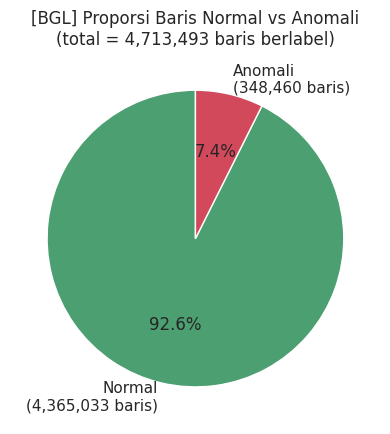

In [13]:
datasets_with_line_labels = [n for n in names if all_results[n]["parsing_stats"]["line_label_counts"]]

if datasets_with_line_labels:
    fig, axes = plt.subplots(1, len(datasets_with_line_labels), figsize=(5 * len(datasets_with_line_labels), 4.5))
    if len(datasets_with_line_labels) == 1:
        axes = [axes]
    for ax, name in zip(axes, datasets_with_line_labels):
        lc = all_results[name]["parsing_stats"]["line_label_counts"]
        total = lc["normal"] + lc["anomaly"]
        wedges, texts, autotexts = ax.pie(
            [lc["normal"], lc["anomaly"]], labels=[f"Normal\n({lc['normal']:,} baris)", f"Anomali\n({lc['anomaly']:,} baris)"],
            autopct="%1.1f%%", colors=["#4C9F70", "#D1495B"], startangle=90)
        ax.set_title(f"[{name}] Proporsi Baris Normal vs Anomali\n(total = {total:,} baris berlabel)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "line_label_proportion.png"), dpi=150)
    plt.show()
else:
    print("Tidak ada dataset dengan label per baris (HDFS berlabel per Block ID, ditampilkan di bagian sekuens).")

## 10. Tabel Ringkasan Statistik Sekuens (Lintas Dataset)

In [14]:
seq_rows = []
for name, res in all_results.items():
    ss = res["seq_stats"]
    seq_rows.append({
        "Dataset"                 : name,
        "Skema"                   : res["scheme"],
        "Jumlah Sekuens"          : ss["n_sequences"],
        "Sekuens Normal"          : ss["label_counts"]["normal"],
        "Sekuens Anomali"         : ss["label_counts"]["anomaly"],
        "Sekuens Unknown"         : ss["label_counts"]["unknown"],
        "Panjang Sekuens (median)": ss["seq_length_stats"]["median"],
        "Panjang Sekuens (mean)"  : round(ss["seq_length_stats"]["mean"], 2),
        "Panjang Sekuens (P90)"   : ss["seq_length_stats"]["p90"],
        "Panjang Sekuens (max)"   : ss["seq_length_stats"]["max"],
        "Template Unik/Sekuens (mean)": round(ss["unique_template_per_seq_stats"]["mean"], 2),
    })

seq_summary_df = pd.DataFrame(seq_rows)
seq_summary_df

,Dataset,Skema,Jumlah Sekuens,Sekuens Normal,Sekuens Anomali,Sekuens Unknown,Panjang Sekuens (median),Panjang Sekuens (mean),Panjang Sekuens (P90),Panjang Sekuens (max),Template Unik/Sekuens (mean)
0,BGL,sliding-window (size=20),235674,215418,20256,0,20.0,20.00,20.0,20,1.42
1,HDFS,HDFS block-ID,575061,558223,16838,0,22.0,21.87,28.0,310,7.25


### Visualisasi: Jumlah Sekuens & Distribusi Label Sekuens

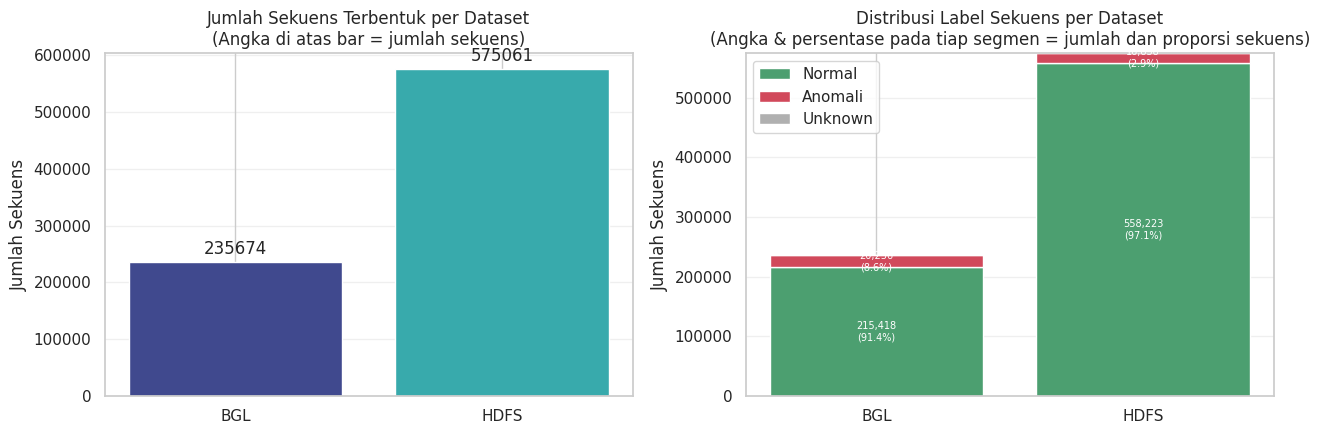

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# -- Jumlah sekuens per dataset --
n_seqs = [all_results[n]["seq_stats"]["n_sequences"] for n in names]
bars = axes[0].bar(names, n_seqs, color=sns.color_palette("mako", len(names)))
axes[0].bar_label(bars, fmt="%d", padding=3)
axes[0].set_ylabel("Jumlah Sekuens")
axes[0].set_title("Jumlah Sekuens Terbentuk per Dataset\n(Angka di atas bar = jumlah sekuens)")
axes[0].grid(axis="y", alpha=0.3)

# -- Distribusi label sekuens (stacked bar: normal/anomali/unknown) --
normal_c  = [all_results[n]["seq_stats"]["label_counts"]["normal"] for n in names]
anomaly_c = [all_results[n]["seq_stats"]["label_counts"]["anomaly"] for n in names]
unknown_c = [all_results[n]["seq_stats"]["label_counts"]["unknown"] for n in names]

x = np.arange(len(names))
axes[1].bar(x, normal_c, label="Normal", color="#4C9F70")
axes[1].bar(x, anomaly_c, bottom=normal_c, label="Anomali", color="#D1495B")
bottom2 = np.array(normal_c) + np.array(anomaly_c)
axes[1].bar(x, unknown_c, bottom=bottom2, label="Unknown", color="#B0B0B0")

for xi, nc, ac, uc in zip(x, normal_c, anomaly_c, unknown_c):
    tot = max(1, nc + ac + uc)
    if nc > 0:
        axes[1].text(xi, nc / 2, f"{nc:,}\n({100*nc/tot:.1f}%)", ha="center", va="center", fontsize=7, color="white")
    if ac > 0:
        axes[1].text(xi, nc + ac / 2, f"{ac:,}\n({100*ac/tot:.1f}%)", ha="center", va="center", fontsize=7, color="white")
    if uc > 0:
        axes[1].text(xi, nc + ac + uc / 2, f"{uc:,}\n({100*uc/tot:.1f}%)", ha="center", va="center", fontsize=7)

axes[1].set_xticks(x); axes[1].set_xticklabels(names)
axes[1].set_ylabel("Jumlah Sekuens")
axes[1].set_title("Distribusi Label Sekuens per Dataset\n(Angka & persentase pada tiap segmen = jumlah dan proporsi sekuens)")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sequence_counts_and_labels.png"), dpi=150)
plt.show()

### Visualisasi: Distribusi Panjang Sekuens (Jumlah Baris Log per Sekuens)

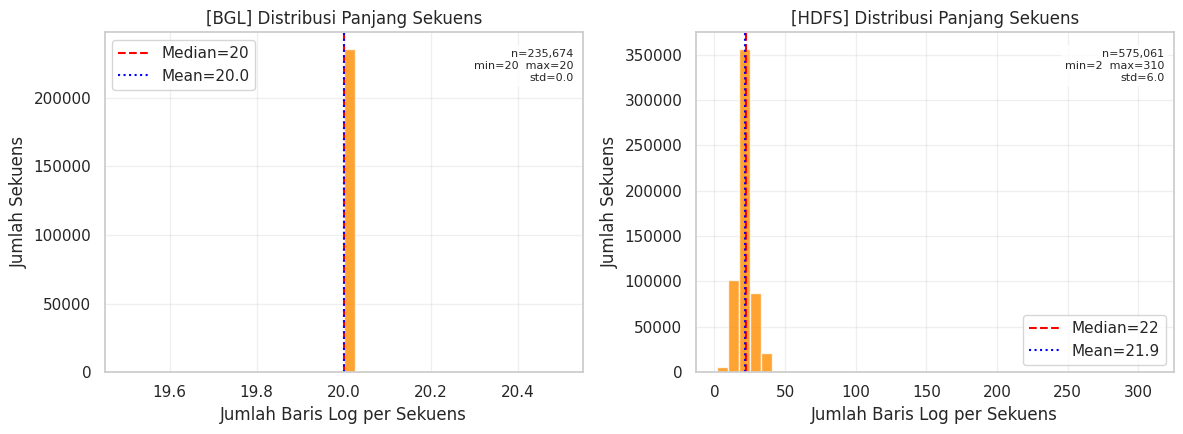

In [16]:
fig, axes = plt.subplots(1, len(all_results), figsize=(6 * len(all_results), 4.5), squeeze=False)
axes = axes[0]

for ax, name in zip(axes, all_results.keys()):
    seq_lengths = all_results[name]["seq_lengths"]
    ax.hist(seq_lengths, bins=40, color="darkorange", alpha=0.8)
    med = np.median(seq_lengths)
    mean = np.mean(seq_lengths)
    ax.axvline(med, color="red", ls="--", label=f"Median={med:.0f}")
    ax.axvline(mean, color="blue", ls=":", label=f"Mean={mean:.1f}")
    stats_txt = (f"n={len(seq_lengths):,}\n"
                 f"min={seq_lengths.min():.0f}  max={seq_lengths.max():.0f}\n"
                 f"std={seq_lengths.std():.1f}")
    ax.text(0.98, 0.95, stats_txt, transform=ax.transAxes, ha="right", va="top",
            fontsize=8, bbox=dict(boxstyle="round", fc="white", alpha=0.8))
    ax.set_title(f"[{name}] Distribusi Panjang Sekuens")
    ax.set_xlabel("Jumlah Baris Log per Sekuens")
    ax.set_ylabel("Jumlah Sekuens")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sequence_length_distribution.png"), dpi=150)
plt.show()

### Visualisasi: Boxplot Perbandingan Panjang Sekuens Antar Dataset

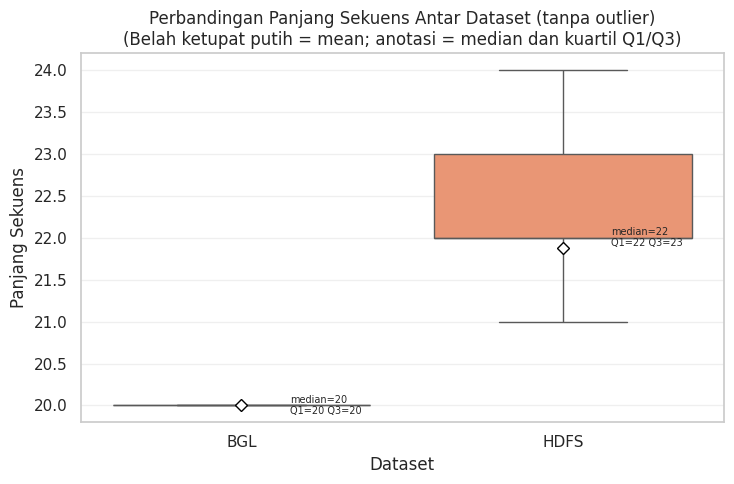

In [17]:
box_data = []
for name in all_results.keys():
    for length in all_results[name]["seq_lengths"]:
        box_data.append({"Dataset": name, "Panjang Sekuens": length})
box_df = pd.DataFrame(box_data)

fig, ax = plt.subplots(figsize=(7.5, 5))
sns.boxplot(data=box_df, x="Dataset", y="Panjang Sekuens", hue="Dataset",
            palette="Set2", showfliers=False, showmeans=True,
            meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":6},
            legend=False, ax=ax)

for i, name in enumerate(all_results.keys()):
    lengths = all_results[name]["seq_lengths"]
    med = np.median(lengths)
    q1, q3 = np.percentile(lengths, [25, 75])
    ax.annotate(f"median={med:.0f}\nQ1={q1:.0f} Q3={q3:.0f}", xy=(i, med), xytext=(i + 0.15, med),
                fontsize=7, va="center")

ax.set_title("Perbandingan Panjang Sekuens Antar Dataset (tanpa outlier)\n(Belah ketupat putih = mean; anotasi = median dan kuartil Q1/Q3)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sequence_length_boxplot.png"), dpi=150)
plt.show()

### Visualisasi: Distribusi Jumlah Template Unik per Sekuens

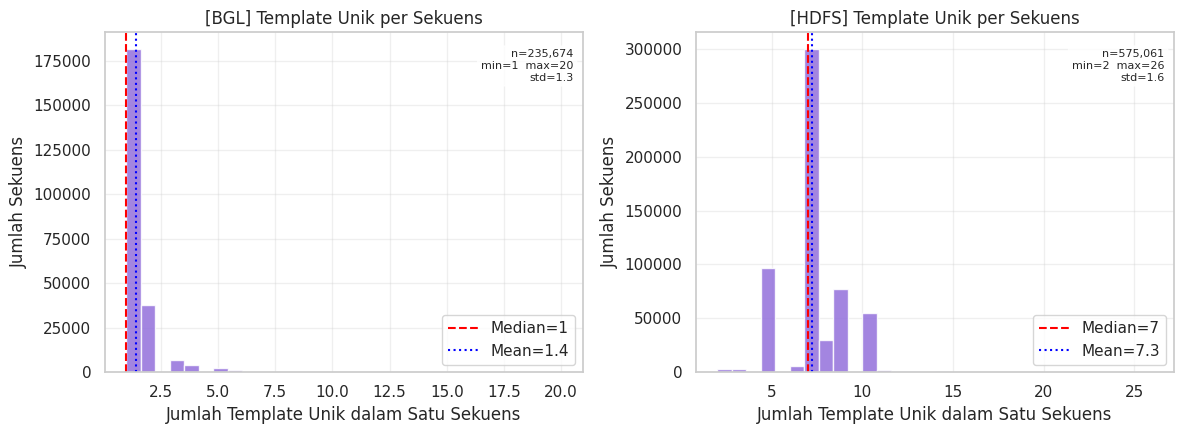

In [18]:
fig, axes = plt.subplots(1, len(all_results), figsize=(6 * len(all_results), 4.5), squeeze=False)
axes = axes[0]

for ax, name in zip(axes, all_results.keys()):
    u = all_results[name]["unique_tpl_per_seq"]
    ax.hist(u, bins=30, color="mediumpurple", alpha=0.85)
    med = np.median(u)
    mean = np.mean(u)
    ax.axvline(med, color="red", ls="--", label=f"Median={med:.0f}")
    ax.axvline(mean, color="blue", ls=":", label=f"Mean={mean:.1f}")
    stats_txt = f"n={len(u):,}\nmin={u.min():.0f}  max={u.max():.0f}\nstd={u.std():.1f}"
    ax.text(0.98, 0.95, stats_txt, transform=ax.transAxes, ha="right", va="top",
            fontsize=8, bbox=dict(boxstyle="round", fc="white", alpha=0.8))
    ax.set_title(f"[{name}] Template Unik per Sekuens")
    ax.set_xlabel("Jumlah Template Unik dalam Satu Sekuens")
    ax.set_ylabel("Jumlah Sekuens")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "unique_templates_per_sequence.png"), dpi=150)
plt.show()

## 11. Statistik Deskriptif Rinci (Output Tambahan)

Selain tabel ringkasan dan grafik di atas, bagian ini menghasilkan **deskripsi statistik yang lebih rinci** untuk setiap dataset, disimpan sebagai berkas terpisah (CSV/TXT) di `OUTPUT_DIR`:

1. `template_frequencies_<dataset>.csv` — **setiap template unik** beserta jumlah kemunculan, persentase terhadap total baris, dan persentase kumulatif (diurutkan dari yang paling sering).
2. `descriptive_stats_sequence_length_<dataset>.csv` — statistik deskriptif lengkap (count, mean, std, min, kuartil, max) untuk **panjang sekuens**.
3. `descriptive_stats_unique_templates_per_seq_<dataset>.csv` — statistik deskriptif lengkap untuk **jumlah template unik per sekuens**.
4. `descriptive_stats_all_datasets.csv` — gabungan statistik deskriptif (panjang sekuens & template unik/sekuens) lintas dataset dalam satu tabel.
5. `statistics_report.txt` — laporan naratif ringkas berisi seluruh angka penting (jumlah baris, template, sekuens, dsb.) dalam format teks yang mudah dibaca/disalin ke laporan.

In [19]:
# ── Statistik deskriptif lengkap (count, mean, std, min, 25%, 50%, 75%, max) ──
desc_rows = []
for name, res in all_results.items():
    seq_len_desc = pd.Series(res["seq_lengths"]).describe()
    uniq_desc    = pd.Series(res["unique_tpl_per_seq"]).describe()

    # simpan per-dataset
    seq_len_desc.rename("Panjang Sekuens").to_frame().to_csv(
        os.path.join(OUTPUT_DIR, f"descriptive_stats_sequence_length_{name}.csv"))
    uniq_desc.rename("Template Unik per Sekuens").to_frame().to_csv(
        os.path.join(OUTPUT_DIR, f"descriptive_stats_unique_templates_per_seq_{name}.csv"))

    desc_rows.append({
        "Dataset": name, "Metrik": "Panjang Sekuens",
        **{k: v for k, v in seq_len_desc.items()},
    })
    desc_rows.append({
        "Dataset": name, "Metrik": "Template Unik per Sekuens",
        **{k: v for k, v in uniq_desc.items()},
    })

descriptive_stats_df = pd.DataFrame(desc_rows)
descriptive_stats_df.to_csv(os.path.join(OUTPUT_DIR, "descriptive_stats_all_datasets.csv"), index=False)
descriptive_stats_df

,Dataset,Metrik,count,mean,std,min,25%,50%,75%,max
0,BGL,Panjang Sekuens,235674.0,20.000000,0.000000,20.0,20.0,20.0,20.0,20.0
1,BGL,Template Unik per Sekuens,235674.0,1.419410,1.270175,1.0,1.0,1.0,1.0,20.0
2,HDFS,Panjang Sekuens,575061.0,21.871914,6.034524,2.0,22.0,22.0,23.0,310.0
3,HDFS,Template Unik per Sekuens,575061.0,7.252559,1.579822,2.0,7.0,7.0,8.0,26.0


## 11. Simpan Semua Statistik ke Disk

In [20]:
# ── JSON gabungan: statistik parsing + sekuens per dataset ──────────────
export_stats = {}
for name, res in all_results.items():
    export_stats[name] = {
        "scheme"       : res["scheme"],
        "parsing_stats": res["parsing_stats"],
        "seq_stats"    : res["seq_stats"],
    }

with open(os.path.join(OUTPUT_DIR, "parsing_and_sequence_stats.json"), "w") as f:
    json.dump(export_stats, f, indent=2)

# ── CSV ringkasan (tabel lintas dataset) ─────────────────────────────────
parsing_summary_df.to_csv(os.path.join(OUTPUT_DIR, "parsing_summary.csv"), index=False)
seq_summary_df.to_csv(os.path.join(OUTPUT_DIR, "sequence_summary.csv"), index=False)

# ── CSV frekuensi template lengkap per dataset (dengan persentase & kumulatif) ──
for name, res in all_results.items():
    n_lines_ok = res["parsing_stats"]["lines_parsed_ok"]
    tpl_df = res["template_counts"].rename_axis("template").reset_index(name="count")
    tpl_df["pct_of_lines"] = (100 * tpl_df["count"] / max(1, n_lines_ok)).round(3)
    tpl_df["cumulative_pct"] = tpl_df["pct_of_lines"].cumsum().round(3)
    tpl_df.insert(0, "rank", np.arange(1, len(tpl_df) + 1))
    tpl_df.to_csv(os.path.join(OUTPUT_DIR, f"template_frequencies_{name}.csv"), index=False)

# ── Laporan naratif ringkas (statistics_report.txt) ──────────────────────
report_lines = []
report_lines.append("=" * 78)
report_lines.append("LAPORAN STATISTIK PARSING & PEMBENTUKAN SEKUENS")
report_lines.append("=" * 78)
for name, res in all_results.items():
    ps = res["parsing_stats"]
    ss = res["seq_stats"]
    report_lines.append(f"\n--- Dataset: {name} ({res['scheme']}) ---")
    report_lines.append(f"Total baris dibaca        : {ps['total_lines_read']:,}")
    report_lines.append(f"Baris berhasil diparsing  : {ps['lines_parsed_ok']:,} ({ps['parse_success_rate']:.2%})")
    report_lines.append(f"Baris gagal diparsing     : {ps['lines_failed_parse']:,}")
    report_lines.append(f"Jumlah template unik      : {ps['n_unique_templates']:,}")
    tf = ps["template_freq_stats"]
    report_lines.append(f"Frekuensi template (min/median/mean/max): {tf['min']:,} / {tf['median']:.1f} / {tf['mean']:.1f} / {tf['max']:,}")
    if ps["line_label_counts"]:
        lc = ps["line_label_counts"]
        tot = lc["normal"] + lc["anomaly"]
        report_lines.append(f"Baris normal / anomali    : {lc['normal']:,} ({100*lc['normal']/max(1,tot):.1f}%) / {lc['anomaly']:,} ({100*lc['anomaly']/max(1,tot):.1f}%)")
    report_lines.append(f"Jumlah sekuens terbentuk  : {ss['n_sequences']:,}")
    lcs = ss["label_counts"]
    tot_seq = max(1, ss["n_sequences"])
    report_lines.append(f"  Normal  : {lcs['normal']:,} ({100*lcs['normal']/tot_seq:.1f}%)")
    report_lines.append(f"  Anomali : {lcs['anomaly']:,} ({100*lcs['anomaly']/tot_seq:.1f}%)")
    report_lines.append(f"  Unknown : {lcs['unknown']:,} ({100*lcs['unknown']/tot_seq:.1f}%)")
    sl = ss["seq_length_stats"]
    report_lines.append(f"Panjang sekuens (min/median/mean/p90/p99/max): {sl['min']}/{sl['median']:.1f}/{sl['mean']:.1f}/{sl['p90']:.1f}/{sl['p99']:.1f}/{sl['max']}")
    ut = ss["unique_template_per_seq_stats"]
    report_lines.append(f"Template unik per sekuens (min/median/mean/max): {ut['min']}/{ut['median']:.1f}/{ut['mean']:.1f}/{ut['max']}")
    report_lines.append("Top-5 template paling sering muncul:")
    for t in ps["template_freq_top"][:5]:
        report_lines.append(f"  - [{t['count']:,}x] {t['template']}")

report_text = "\n".join(report_lines)
with open(os.path.join(OUTPUT_DIR, "statistics_report.txt"), "w") as f:
    f.write(report_text)

print(report_text)

print(f"\n\nSemua statistik & grafik tersimpan di: {OUTPUT_DIR}")
print("\nBerkas yang dihasilkan:")
for fn in sorted(os.listdir(OUTPUT_DIR)):
    print(" -", fn)

LAPORAN STATISTIK PARSING & PEMBENTUKAN SEKUENS

--- Dataset: BGL (sliding-window (size=20)) ---
Total baris dibaca        : 4,747,963
Baris berhasil diparsing  : 4,713,493 (99.27%)
Baris gagal diparsing     : 34,470
Jumlah template unik      : 1,822
Frekuensi template (min/median/mean/max): 1 / 1.0 / 1974.7 / 1,706,750
Baris normal / anomali    : 4,365,033 (92.6%) / 348,460 (7.4%)
Jumlah sekuens terbentuk  : 235,674
  Normal  : 215,418 (91.4%)
  Anomali : 20,256 (8.6%)
  Unknown : 0 (0.0%)
Panjang sekuens (min/median/mean/p90/p99/max): 20/20.0/20.0/20.0/20.0/20
Template unik per sekuens (min/median/mean/max): 1/1.0/1.4/20
Top-5 template paling sering muncul:
  - [1,706,750x] generating <*>
  - [441,942x] iar <*> dear <*>
  - [295,763x] <*> double-hummer alignment exceptions
  - [267,724x] <*> floating point alignment exceptions
  - [201,205x] CE sym <*> at <*> mask <*>

--- Dataset: HDFS (HDFS block-ID) ---
Total baris dibaca        : 11,175,629
Baris berhasil diparsing  : 11,175,629 

In [21]:
import shutil
import os

print("\n=== MEMULAI PROSES KOMPRESI ===")
zip_output_path = '/kaggle/working/outputs_parsing_stats'

try:
    # Mengompresi folder outputs_parsing_stats menjadi file .zip
    shutil.make_archive(zip_output_path, 'zip', OUTPUT_DIR)

    if os.path.exists(f"{zip_output_path}.zip"):
        size_mb = os.path.getsize(f"{zip_output_path}.zip") / (1024 * 1024)
        print(f"[SUKSES] Folder {OUTPUT_DIR} berhasil dikompresi!")
        print(f"[INFO] File ZIP disimpan di : {zip_output_path}.zip")
        print(f"[INFO] Ukuran File ZIP      : {size_mb:.2f} MB")
    else:
        print("[GAGAL] File ZIP tidak ditemukan setelah proses kompresi.")
except Exception as e:
    print(f"[ERROR] Terjadi kesalahan saat kompresi: {str(e)}")


=== MEMULAI PROSES KOMPRESI ===
[SUKSES] Folder /kaggle/working/outputs_parsing_stats berhasil dikompresi!
[INFO] File ZIP disimpan di : /kaggle/working/outputs_parsing_stats.zip
[INFO] Ukuran File ZIP      : 0.98 MB
